In [1]:
import numpy as np
# STAGE 1: SYSTEM SPECIFICATIONS & INITIALIZATION CONSTANTS
M = 4               # Matrix Rows (Delay bins / Frequency subcarriers)
N = 4               # Matrix Columns (Doppler bins / Time slots)
Delta_f = 1000      # Subcarrier frequency spacing (1 kHz)
T = 1 / Delta_f     # Duration of a single useful time slot window (1 ms)
N_CP = 2            # Cyclic Prefix sample length per slot segment
samples_per_slot = M 
oversampling_factor = 4  # Interpolation factor to simulate continuous analog voltage traces

print("--- 16-QAM OTFS HARDWARE VERIFICATION MODEL ---")
print(f"Grid Geometry: {M} Subcarriers x {N} Time Slots")
print(f"Subcarrier Bandwidth: {Delta_f} Hz | Useful Slot Boundary: {T*1000:.1f} ms\n")

--- 16-QAM OTFS HARDWARE VERIFICATION MODEL ---
Grid Geometry: 4 Subcarriers x 4 Time Slots
Subcarrier Bandwidth: 1000 Hz | Useful Slot Boundary: 1.0 ms



In [2]:
# STAGE 2: 16-QAM GRAY CONSTELLATION MAPPING & GEOMETRIC MATRIX LOADING
# Total bits required for a single transmission frame = M * N * 4 bits (16-QAM)
np.random.seed(42)  # Set static seed for reproducible RTL bit-matching
total_bits_needed = M * N * 4
raw_bitstream = np.random.randint(0, 2, total_bits_needed)

# 16-QAM Gray Code Lookup Map (Maps bit pairs to physical coordinate scales)
gray_lut = {(0,0): -3, (0,1): -1, (1,1): +1, (1,0): +3}
nibbles = raw_bitstream.reshape(M * N, 4)
qam_symbols = []

for nibble in nibbles:
    i_coordinate = gray_lut[(nibble[0], nibble[1])]
    q_coordinate = gray_lut[(nibble[2], nibble[3])]
    qam_symbols.append(complex(i_coordinate, q_coordinate))

# Pack complex symbols row-major into the spatial Delay-Doppler Matrix D
D = np.array(qam_symbols).reshape(M, N)

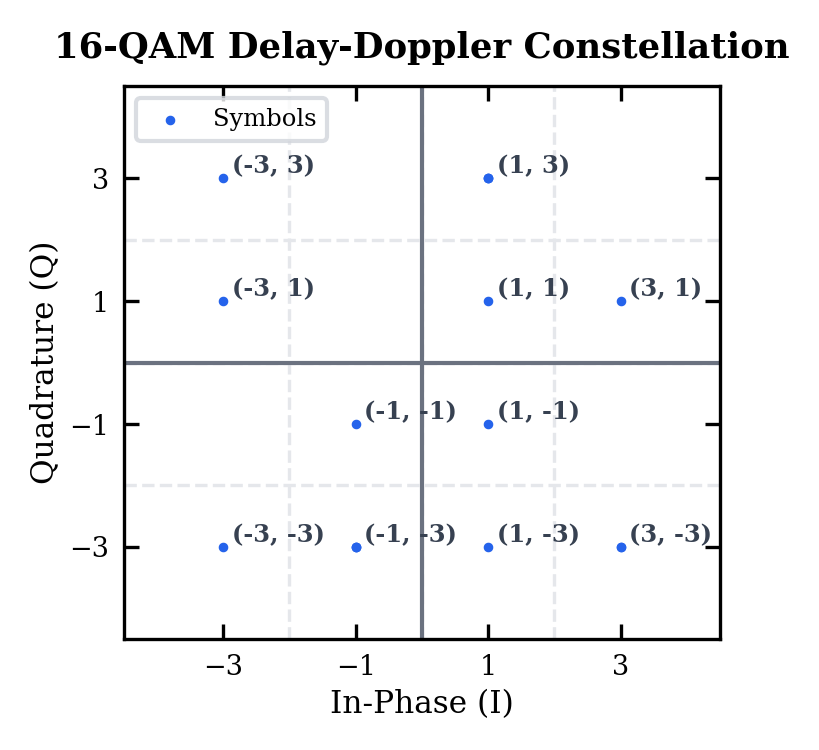

In [3]:
import matplotlib.pyplot as plt

# VISUALIZATION CHECKPOINT: COMPACT 16-QAM CONSTELLATION FOR REPORT
extracted_symbols = D.flatten()
i_coords = [s.real for s in extracted_symbols]
q_coords = [s.imag for s in extracted_symbols]

plt.figure(figsize=(2.6, 2.6), dpi=300)
plt.rcParams['font.family'] = 'serif'

# Custom gray dashed decision boundaries
for line in [-2, 0, 2]:
    plt.axvline(x=line, color='#e5e7eb', linestyle='--', linewidth=0.8, zorder=1)
    plt.axhline(y=line, color='#e5e7eb', linestyle='--', linewidth=0.8, zorder=1)

# Solid baseline coordinate axes
plt.axvline(x=0, color='#6b7280', linestyle='-', linewidth=1.0, zorder=2)
plt.axhline(y=0, color='#6b7280', linestyle='-', linewidth=1.0, zorder=2)

# Make the dots much smaller: reduce marker size to 6 and remove thick border
plt.scatter(i_coords, q_coords, color='#2563eb', 
            s=4, linewidths=0.3, marker='o', label='Symbols', zorder=3)

# Compact coordinate labels placed tightly next to the states
unique_points = list(set(zip(i_coords, q_coords)))
for (i, q) in unique_points:
    plt.text(i + 0.13, q + 0.08, f"({int(i)}, {int(q)})", 
             color='#374151', fontsize=5.8, fontweight='bold', zorder=4)

# Plot constraints and formatting configurations
ax = plt.gca()
ax.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
ax.tick_params(colors='black', labelsize=6.5, direction='in', top=True, right=True)
ax.grid(False)

# Fixed axis boundaries
plt.xlim(-4.5, 4.5)
plt.ylim(-4.5, 4.5)
plt.xticks([-3, -1, 1, 3])
plt.yticks([-3, -1, 1, 3])

# Clean, professional text framing
plt.title('16-QAM Delay-Doppler Constellation', color='black', fontsize=8.5, pad=7, fontweight='bold')
plt.xlabel('In-Phase (I)', color='black', fontsize=7.5, labelpad=2)
plt.ylabel('Quadrature (Q)', color='black', fontsize=7.5, labelpad=2)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#d1d5db', fontsize=5.8)

plt.tight_layout()
plt.show()

In [4]:
# STAGE 3: ISFFT DOMAIN TRANSFORMATION (THE MATRIX OPERATOR SANDWICH)
# =====================================================================
# Generate scale-normalized forward and inverse unitary transformation matrices
W_M = (1.0 / np.sqrt(M)) * np.fft.fft(np.eye(M))
W_N_inv = (1.0 / np.sqrt(N)) * np.fft.ifft(np.eye(N)) * N  # Normalized scaling factor
# Execute 2D matrix transformation to yield Time-Frequency Grid X_TF
X_TF = np.dot(np.dot(W_M, D), W_N_inv)

In [5]:
# =====================================================================
# STAGE 4: HEISENBERG SYNTHESIS (THE HARDWARE RTL WAY)
# =====================================================================
# The discrete Heisenberg Transform applies an M-point IFFT along the 
# subcarriers (rows) of each independent time slot (columns).

# Apply unitary IFFT down the columns (axis=0). 
# np.fft.ifft divides by M, so we multiply by sqrt(M) to maintain unitary power scaling.
time_domain_slots = np.fft.ifft(X_TF, axis=0) * np.sqrt(M)


In [6]:
import numpy as np

# =====================================================================
# COMPLEX BASEBAND INTERPOLATION AND RF UPCONVERSION
# =====================================================================
# Serialize the 2-D Heisenberg output into one streaming transmit frame.
final_tx_signal = time_domain_slots.flatten(order='F')

# Keep the full complex samples so both I and Q survive the transmit chain.
tx_complex_samples = np.asarray(final_tx_signal, dtype=complex)
sample_indices = np.arange(len(tx_complex_samples))

# Continuous time axis, expressed in sample periods first and then seconds.
t_analog = np.linspace(0, len(tx_complex_samples) - 1, 1000)
Ts = 1.0 / (M * Delta_f)
t_seconds = t_analog * Ts

# Sinc-interpolate I and Q separately.
i_analog_wave = np.zeros_like(t_analog, dtype=float)
q_analog_wave = np.zeros_like(t_analog, dtype=float)

for n, symbol in enumerate(tx_complex_samples):
    basis = np.sinc(t_analog - n)
    i_analog_wave += symbol.real * basis
    q_analog_wave += symbol.imag * basis

# Complex baseband envelope that would normally be used inside the modem.
complex_baseband_wave = i_analog_wave + 1j * q_analog_wave

# Real passband waveform that can be driven into a DAC / antenna chain.
fc = 10_000.0
rf_tx_signal = np.real(complex_baseband_wave * np.exp(1j * 2 * np.pi * fc * t_seconds))

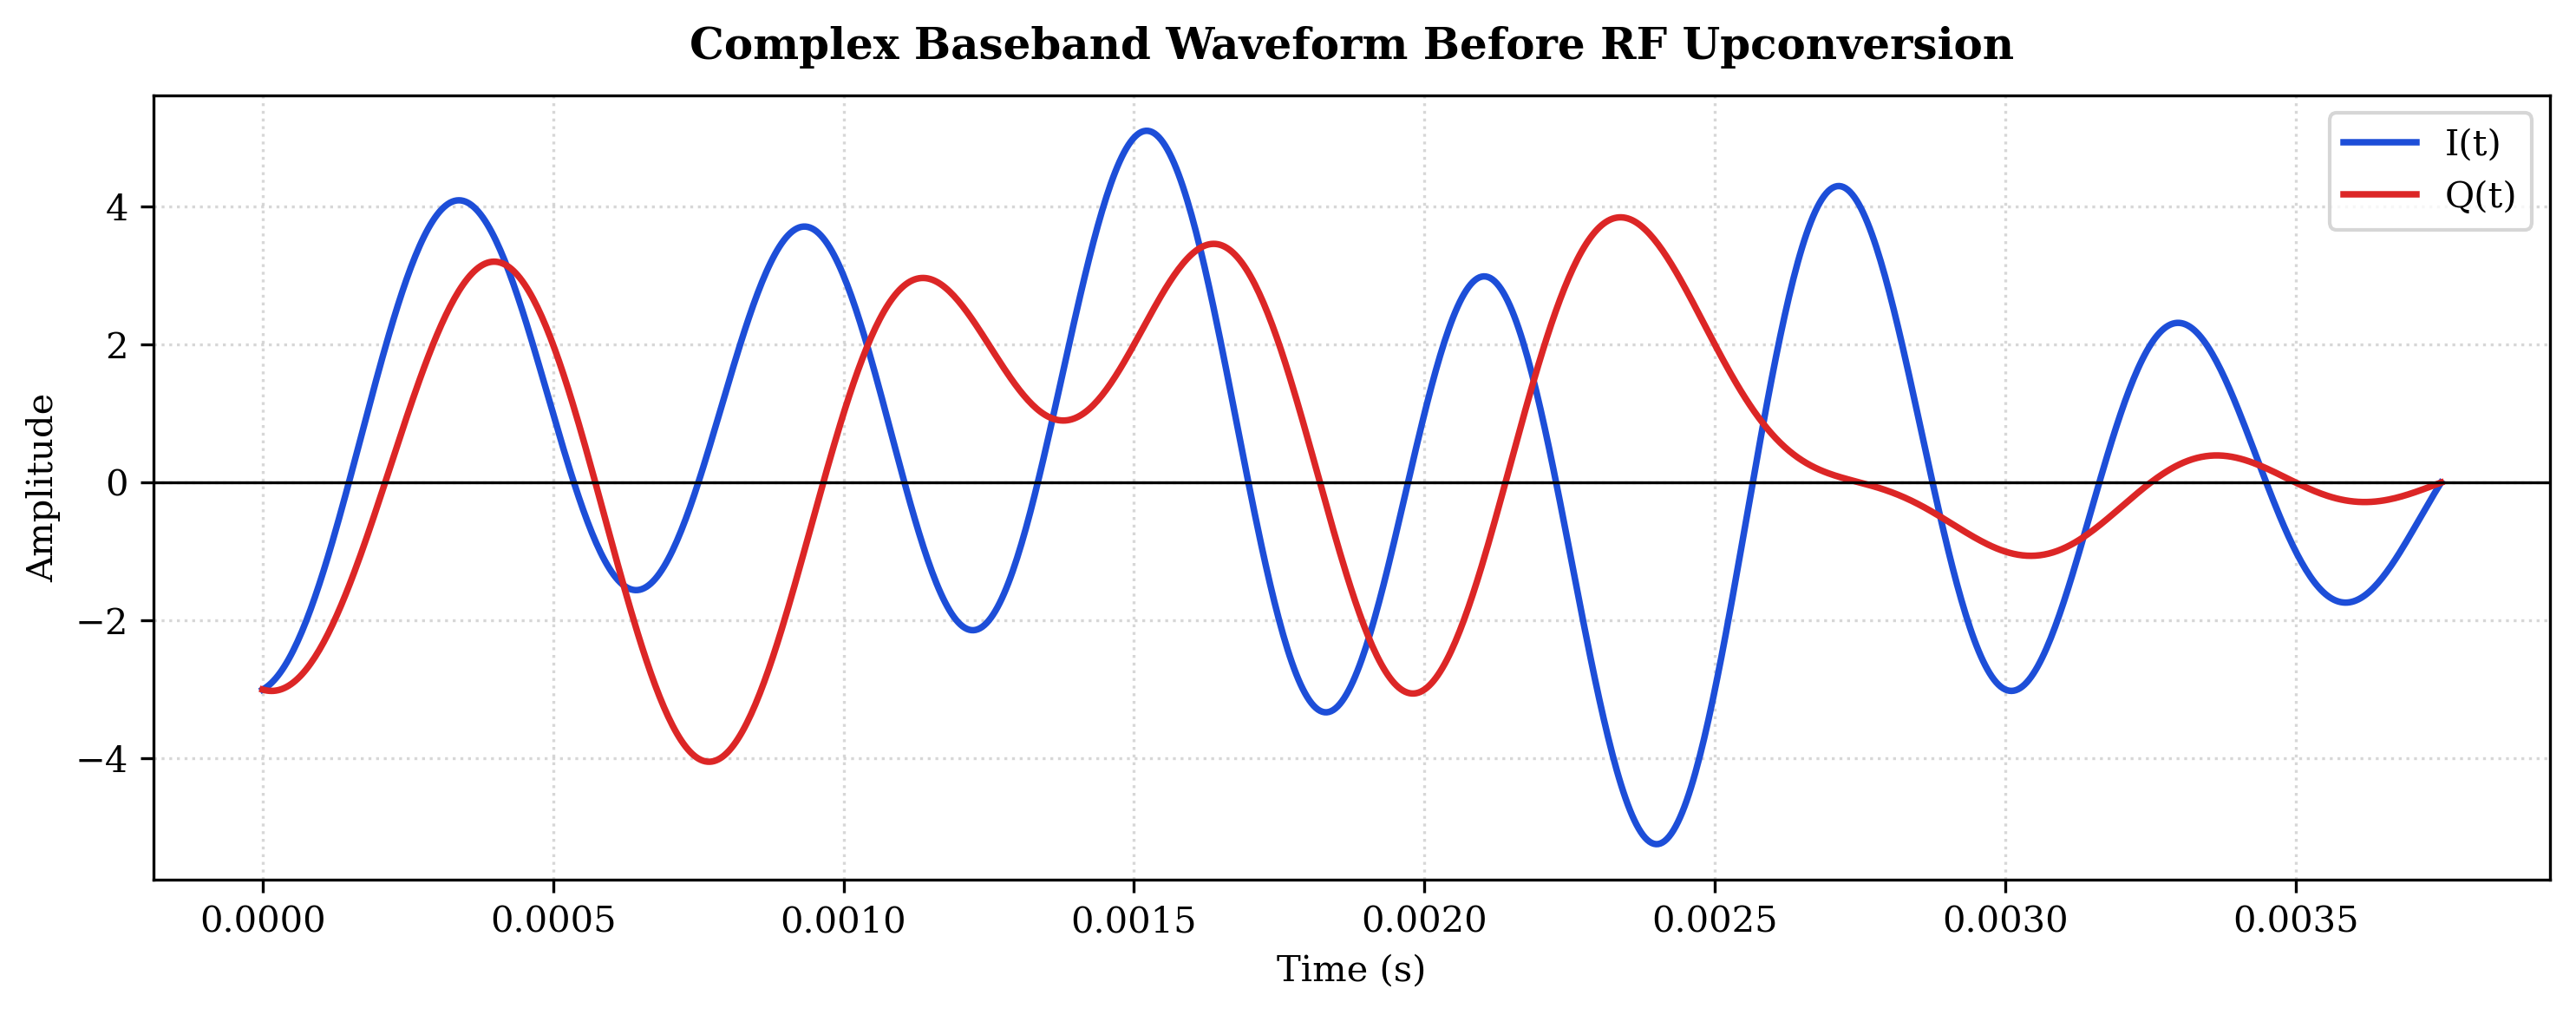

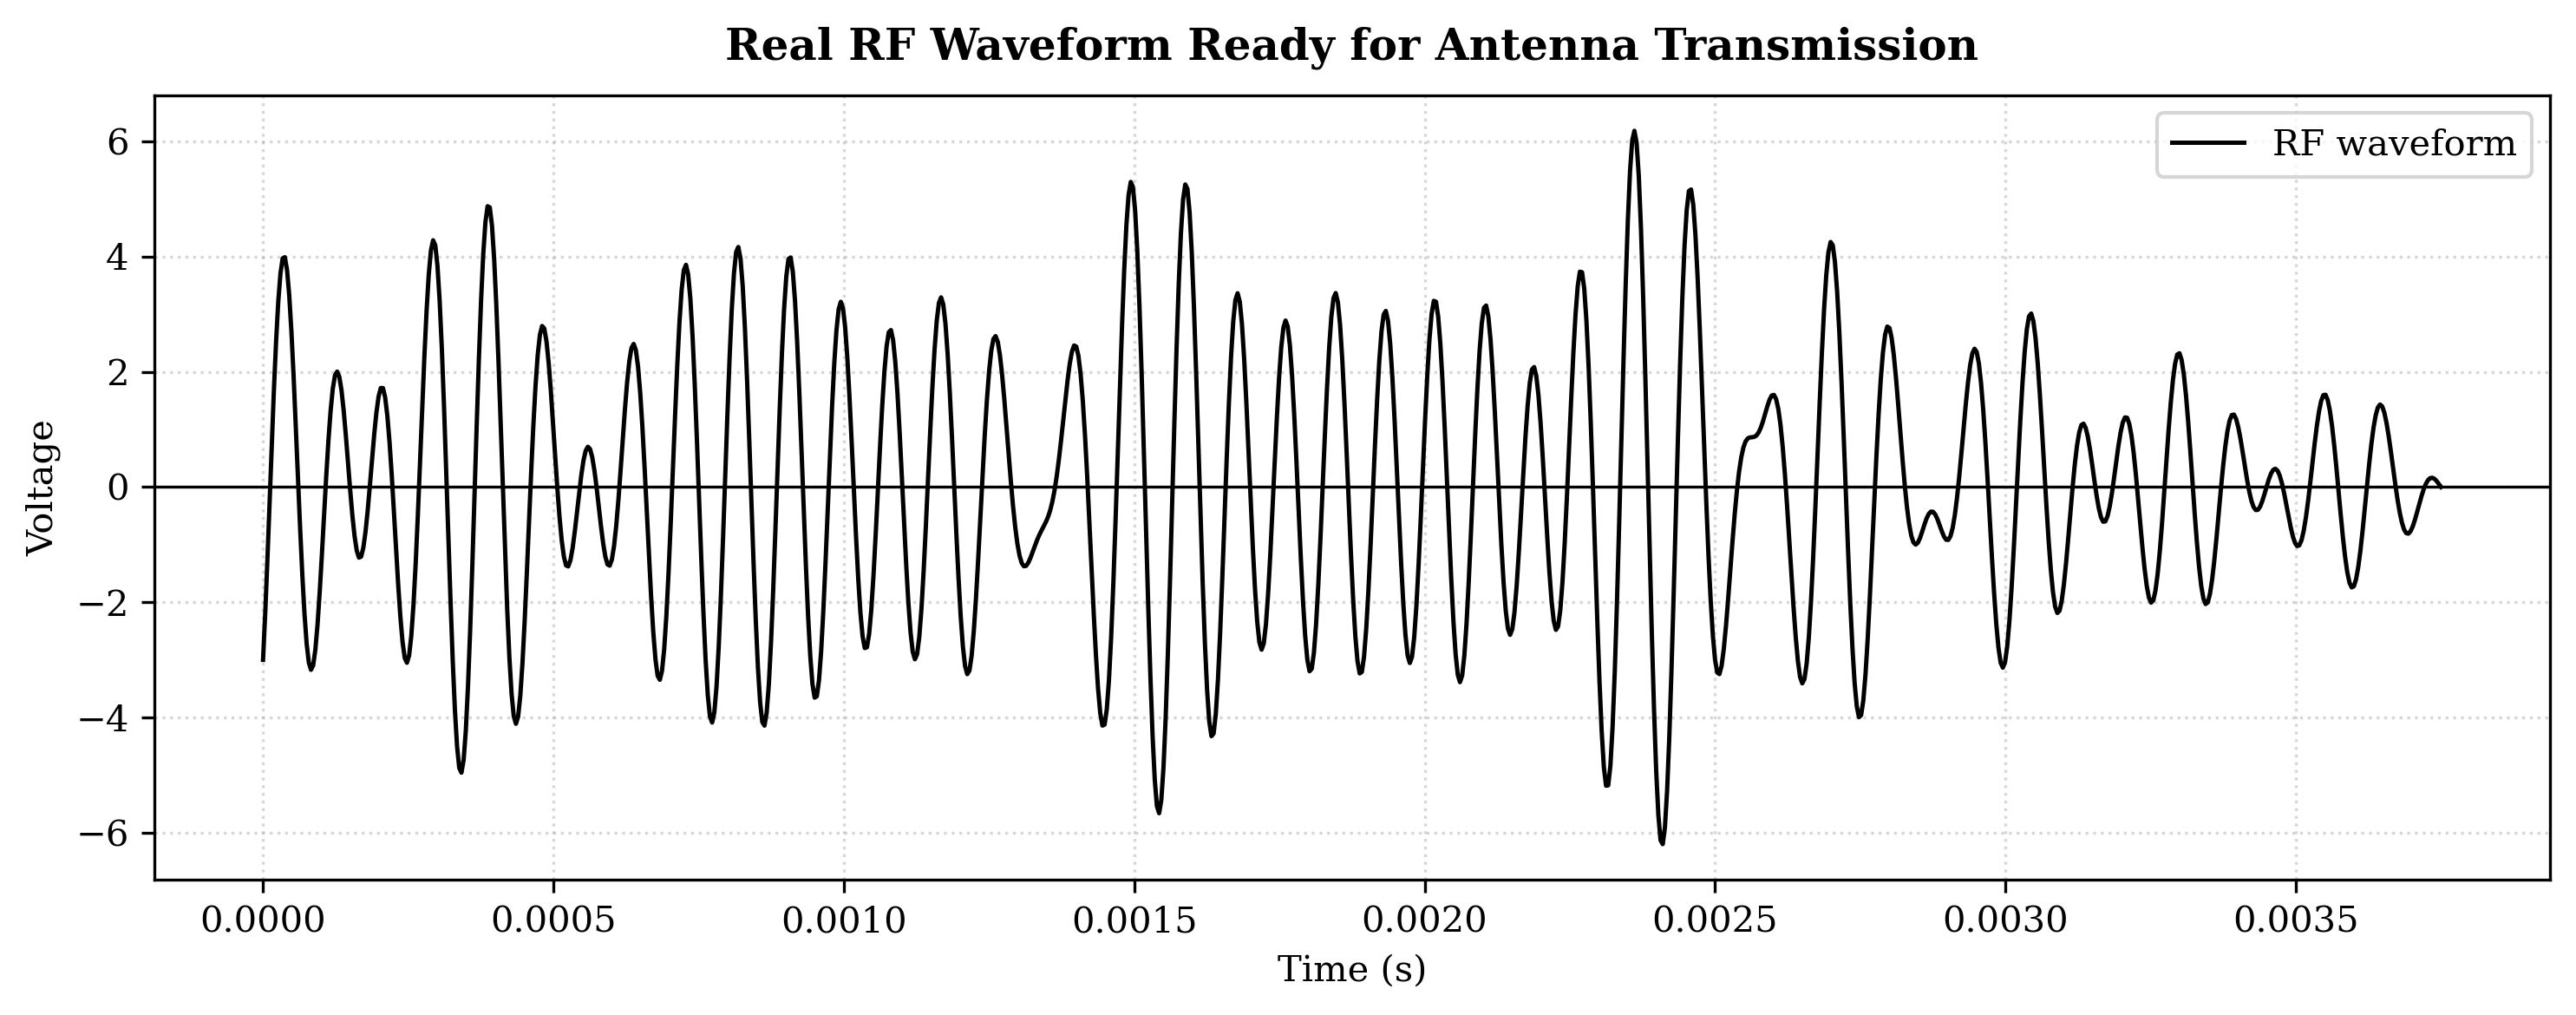

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4), dpi=300)
plt.plot(t_seconds, i_analog_wave, color='#1d4ed8', linewidth=1.8, label='I(t)')
plt.plot(t_seconds, q_analog_wave, color='#dc2626', linewidth=1.8, label='Q(t)')
plt.title('Complex Baseband Waveform Before RF Upconversion', fontweight='bold', pad=10)
plt.xlabel('Time (s)', fontsize=10)
plt.ylabel('Amplitude', fontsize=10)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4), dpi=300)
plt.plot(t_seconds, rf_tx_signal, color='black', linewidth=1.2, label='RF waveform')
plt.title('Real RF Waveform Ready for Antenna Transmission', fontweight='bold', pad=10)
plt.xlabel('Time (s)', fontsize=10)
plt.ylabel('Voltage', fontsize=10)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

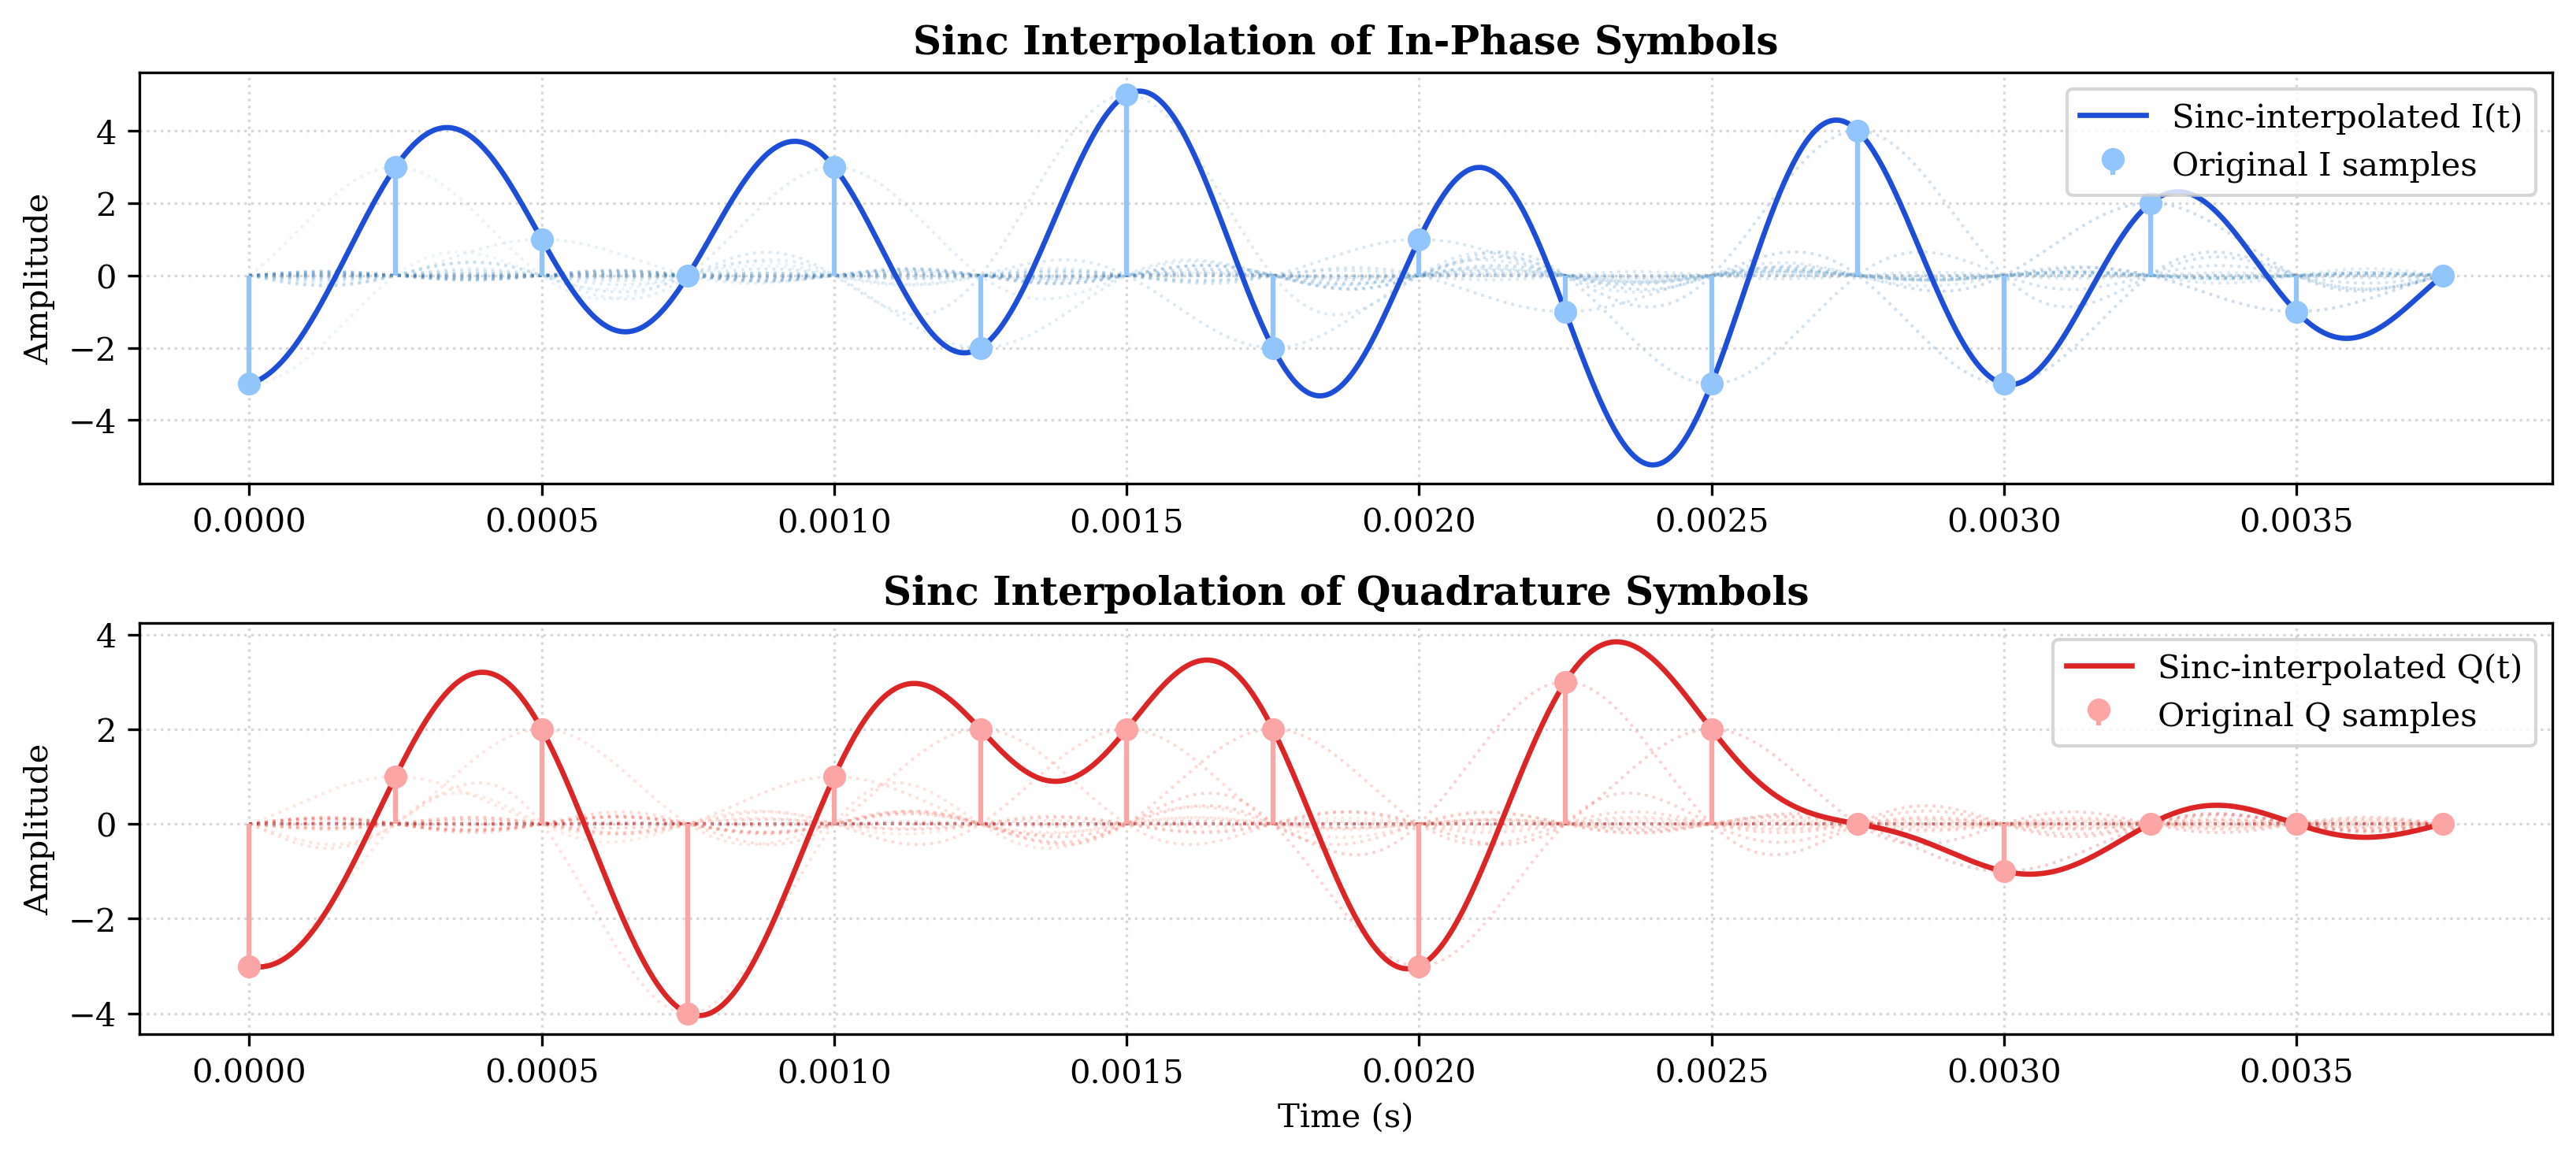

In [13]:
# Sinc interpolation visualization for the transmitted symbols

sample_idx = np.arange(len(tx_complex_samples))
sinc_colors_i = plt.cm.Blues(np.linspace(0.35, 0.85, len(tx_complex_samples)))
sinc_colors_q = plt.cm.Reds(np.linspace(0.35, 0.85, len(tx_complex_samples)))

plt.figure(figsize=(11, 5), dpi=300)

# I-channel
plt.subplot(2, 1, 1)
for n, sample in enumerate(tx_complex_samples.real):
    plt.plot(t_seconds, sample * np.sinc(t_analog - n), color=sinc_colors_i[n], linestyle=':', linewidth=0.9, alpha=0.22, zorder=1)
plt.plot(t_seconds, i_analog_wave, color='#1d4ed8', linewidth=1.6, label='Sinc-interpolated I(t)', zorder=2)
plt.stem(sample_idx * Ts, tx_complex_samples.real, linefmt='#93c5fd', markerfmt='o', basefmt=' ', label='Original I samples')
plt.title('Sinc Interpolation of In-Phase Symbols', fontweight='bold')
plt.ylabel('Amplitude')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')

# Q-channel
plt.subplot(2, 1, 2)
for n, sample in enumerate(tx_complex_samples.imag):
    plt.plot(t_seconds, sample * np.sinc(t_analog - n), color=sinc_colors_q[n], linestyle=':', linewidth=0.9, alpha=0.22, zorder=1)
plt.plot(t_seconds, q_analog_wave, color='#dc2626', linewidth=1.6, label='Sinc-interpolated Q(t)', zorder=2)
plt.stem(sample_idx * Ts, tx_complex_samples.imag, linefmt='#fca5a5', markerfmt='o', basefmt=' ', label='Original Q samples')
plt.title('Sinc Interpolation of Quadrature Symbols', fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Receiver Side: Undoing the Transmit Chain

The transmitter above is intentionally idealized so the signal chain is easy to follow. To complete the learning loop, the next cell adds a simple receiver that assumes perfect timing, a flat complex channel gain, and AWGN only. That is enough to show how the Heisenberg output is turned back into the Delay-Doppler grid and how the 16-QAM symbols are recovered.


--- Receiver Summary ---
Channel gain: 0.864+0.315j
Transmitted samples: 16
Recovered symbols:   16
Bit errors: 0 / 64
BER: 0.0000


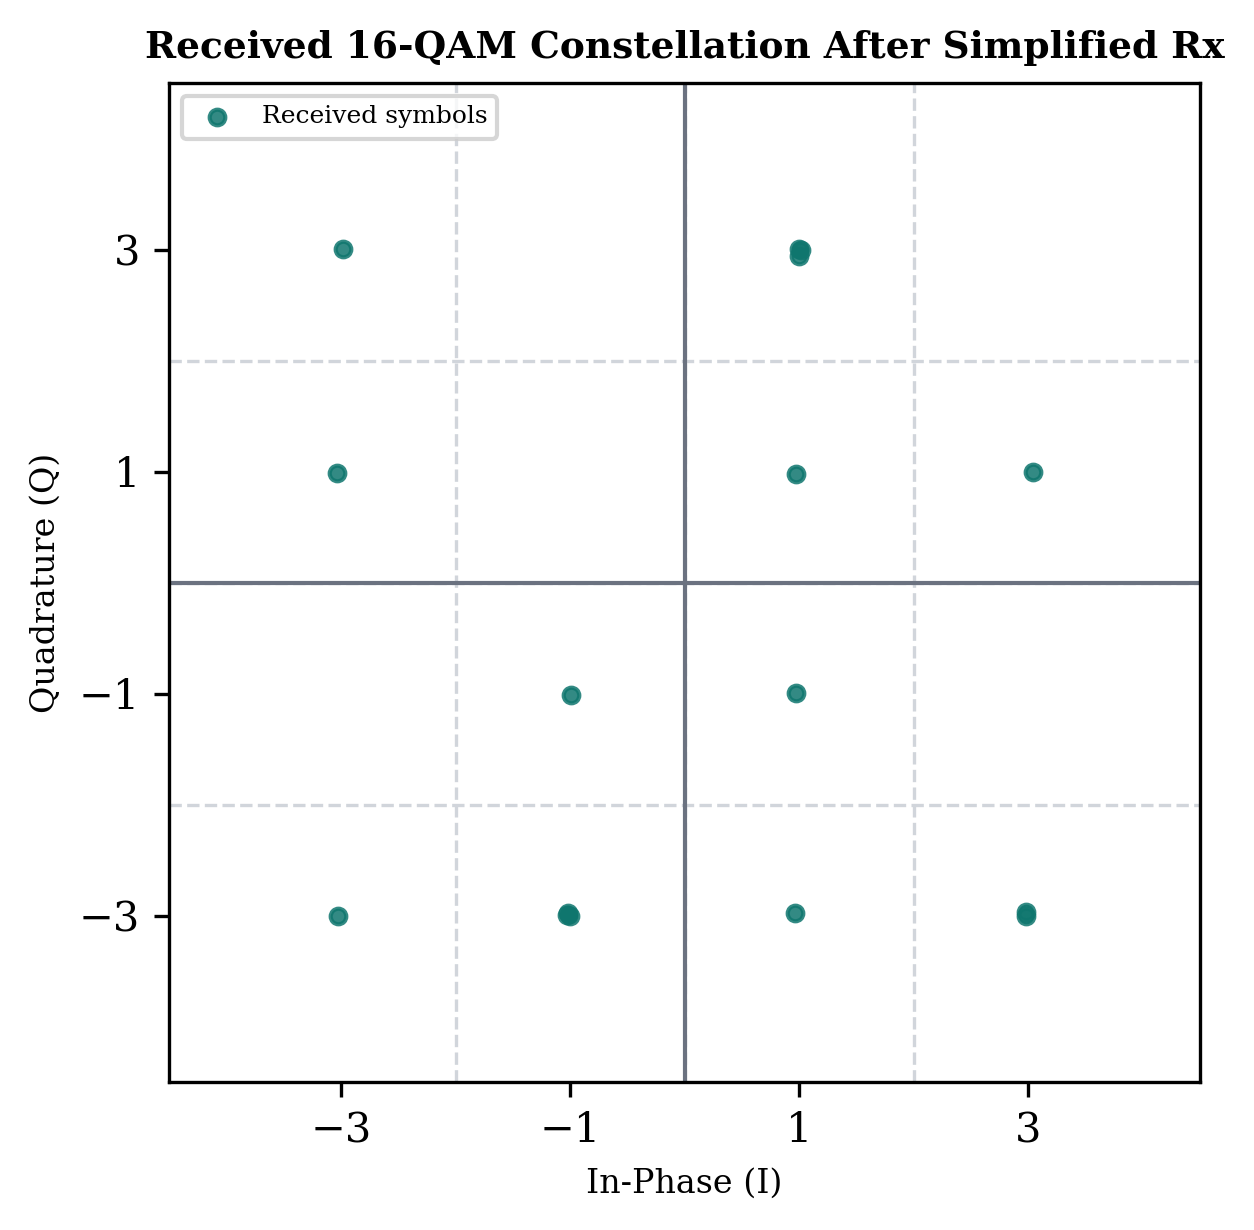

: 

: 